# CIO + Rolling Ball Normalization — Vinc Control

Self-contained notebook. Loads all CZI files from the vinc control folder, applies:
1. Rolling ball background subtraction (r=20, on full-res pax channel)
2. Cell segmentation from ch=1 (Phalloidin)
3. CIO normalization: `(img - mean_outside) / ((mean_inside - mean_outside) * scale)`

Plots overlaid in-cell pixel intensity histograms, one line per image.

In [33]:
# ── paths (edit here) ────────────────────────────────────────────────────────
IMG_DIR  = '/home/lding/lding/fa_data_analysis/fa_data/other_paxillin/20250311_eGFPZyxin488_Phalloidin405_Vinculin(rb)647_paxillin(m)568/Control'
MASK_DIR = '/home/lding/lding/fa_data_analysis/fa_cellseg/031125analysis/control/code_org_20250820_seg/mask'
OUT_PATH = '/home/lding/lding/fa_data_analysis/ae_results/cio_rb_norm_test/vinc_control_histogram.png'

PAX_CH    = 1      # channel used for paxillin
SEG_CH    = 1      # channel used for on-the-fly segmentation (fallback only)
RB_RADIUS = 20     # rolling ball radius on full-resolution image
CIO_SCALE = 5.0    # divisor in CIO formula


In [34]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import czifile
import tifffile
import scipy.ndimage as ndi
from skimage.restoration import rolling_ball
from skimage.morphology import (
    binary_closing, binary_opening, disk, remove_small_objects,
)
from skimage.measure import label, regionprops

Path(OUT_PATH).parent.mkdir(parents=True, exist_ok=True)


In [35]:
# ── helper functions (self-contained, no repo imports) ────────────────────────

def percentile_stretch(img, lo=1, hi=99):
    p1, p99 = np.percentile(img, lo), np.percentile(img, hi)
    if p99 == p1:
        return np.zeros_like(img, dtype=float)
    out = np.clip(img, p1, p99)
    return (out - p1) / (p99 - p1)


def correct_seg_illumination(img):
    """Gaussian flat-field correction to remove centre-bright vignetting."""
    H, W = img.shape
    y, x = np.meshgrid(np.linspace(-1, 1, H), np.linspace(-1, 1, W), indexing='ij')
    gauss = np.exp(-((x**2 + y**2) / 2.0))
    background = gauss * 8 + 100
    smoothed = ndi.gaussian_filter(img.astype(float), sigma=2, mode='nearest', truncate=3)
    return smoothed * 100.0 / background


def segment_cell(seg_ch_img, threshold=0.1, close_size=11,
                 min_size_initial=3, min_size_post_close=10, min_size_final=30):
    """Segment cell mask from a single-channel image."""
    corrected  = correct_seg_illumination(seg_ch_img)
    normalized = percentile_stretch(corrected)
    mask = normalized > threshold
    mask = remove_small_objects(mask, min_size=min_size_initial, connectivity=1)
    mask = binary_closing(mask, disk(close_size))
    # mask = remove_small_objects(mask, min_size=min_size_post_close, connectivity=1)
    # mask = binary_opening(mask, disk(3))
    mask = ndi.binary_fill_holes(mask)
    # mask = remove_small_objects(mask, min_size=min_size_final, connectivity=1)

    # label_img = label(mask)
    # regions   = regionprops(label_img)
    # if len(regions) <= 1:
    #     return label_img

    # H, W = mask.shape
    # cx, cy = H / 2.0, W / 2.0
    # distances = np.array([abs(r.centroid[0]-cx) + abs(r.centroid[1]-cy) for r in regions])
    # on_border = np.array([
    #     r.bbox[0]==0 or r.bbox[1]==0 or r.bbox[2]==H or r.bbox[3]==W
    #     for r in regions], dtype=bool)
    # sort_idx = np.argsort(distances)
    # out = np.zeros_like(label_img)
    # out[label_img == regions[sort_idx[0]].label] = regions[sort_idx[0]].label
    # if not on_border[sort_idx[1]]:
    #     out[label_img == regions[sort_idx[1]].label] = regions[sort_idx[1]].label
    return mask


def apply_rolling_ball(img, radius):
    """Subtract rolling-ball background. Negatives are kept (not clipped)."""
    bg = rolling_ball(img, radius=radius)
    return img - bg


def cio_normalize(img, seg, scale=5.0):
    """(img - mean_outside) / ((mean_inside - mean_outside) * scale). No clipping (matches coworker formula)."""
    outside = seg == 0
    inside  = seg > 0
    mean_out = float(np.mean(img[outside])) if outside.any() else 0.0
    mean_in  = float(np.mean(img[inside]))  if inside.any()  else mean_out + 1.0
    denom = mean_in - mean_out
    if denom == 0.0:
        denom = 1.0
    return (img - mean_out) / (denom * scale), mean_out, mean_in

Found 50 CZI files
  [ 1/50] lin(rb)647_paxillin(m)568_control-01.czi mean_out=0.0004  mean_in=0.0332  inside=346009 px (33.0%)
  [ 2/50] lin(rb)647_paxillin(m)568_control-02.czi mean_out=0.0003  mean_in=0.0287  inside=319340 px (30.5%)
  [ 3/50] lin(rb)647_paxillin(m)568_control-03.czi mean_out=0.0004  mean_in=0.0448  inside=250450 px (23.9%)
  [ 4/50] lin(rb)647_paxillin(m)568_control-04.czi mean_out=0.0004  mean_in=0.0397  inside=416269 px (39.7%)
  [ 5/50] lin(rb)647_paxillin(m)568_control-05.czi mean_out=0.0003  mean_in=0.0313  inside=236048 px (22.5%)
  [ 6/50] lin(rb)647_paxillin(m)568_control-06.czi mean_out=0.0002  mean_in=0.0283  inside=322585 px (30.8%)
  [ 7/50] lin(rb)647_paxillin(m)568_control-07.czi mean_out=0.0017  mean_in=0.0752  inside=266100 px (25.4%)
  [ 8/50] lin(rb)647_paxillin(m)568_control-08.czi mean_out=0.0012  mean_in=0.1026  inside=274820 px (26.2%)
  [ 9/50] lin(rb)647_paxillin(m)568_control-09.czi mean_out=0.0010  mean_in=0.0783  inside=234792 px (22.4%)


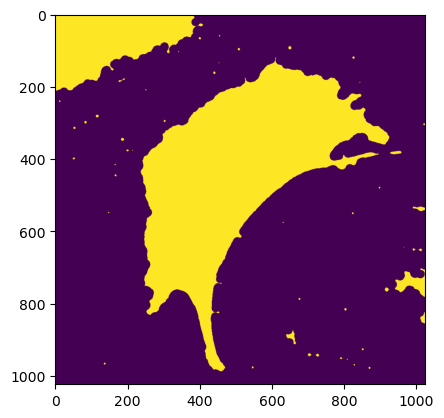

In [36]:
# ── load + process all images ────────────────────────────────────────────────

czis = sorted(Path(IMG_DIR).glob("*.czi"))
print(f"Found {len(czis)} CZI files")

results = []
for idx, p in enumerate(czis):
    print(f"  [{idx+1:2d}/{len(czis)}] {p.name[-40:]}", end=" ", flush=True)

    # Load as uint16-scale float (do NOT divide before rolling ball)
    raw_uint16 = czifile.imread(str(p)).squeeze()
    pax_raw = raw_uint16[PAX_CH].astype(float)  # uint16 scale, e.g. 0-65535

    # ── segmentation mask ───────────────────────────────────────────────
    mask_path = Path(MASK_DIR) / f"cell_mask_{p.name}.tif"
    if mask_path.exists():
        seg = tifffile.imread(str(mask_path))   # uint8 (0 or 255)
        seg = (seg > 0).astype(np.int32)
        print(f"[precomputed mask]  ", end="")
    else:
        seg_ch = raw_uint16[SEG_CH].astype(float)
        seg    = segment_cell(seg_ch)
        print(f"[on-the-fly seg]    ", end="")

    # Apply rolling ball on uint16 scale (radius=20 is meaningful here)
    pax_rb = apply_rolling_ball(pax_raw, RB_RADIUS)

    # CIO normalization is scale-invariant, so uint16 scale is fine
    norm, mean_out, mean_in = cio_normalize(pax_rb, seg, scale=CIO_SCALE)

    inside_vals     = norm[seg > 0]
    raw_inside_vals = pax_raw[seg > 0] / 65535.0   # scale to [0,1] for display
    n_inside = len(inside_vals)
    print(f"mean_out={mean_out:.1f}  mean_in={mean_in:.1f}  inside={n_inside} px ({100*n_inside/norm.size:.1f}%)")
    results.append({"name": p.stem[-20:],
                    "inside_vals":     inside_vals,
                    "raw_inside_vals": raw_inside_vals,
                    "mean_out": mean_out, "mean_in": mean_in})

Saved → /home/lding/lding/fa_data_analysis/ae_results/cio_rb_norm_test/vinc_control_histogram.png


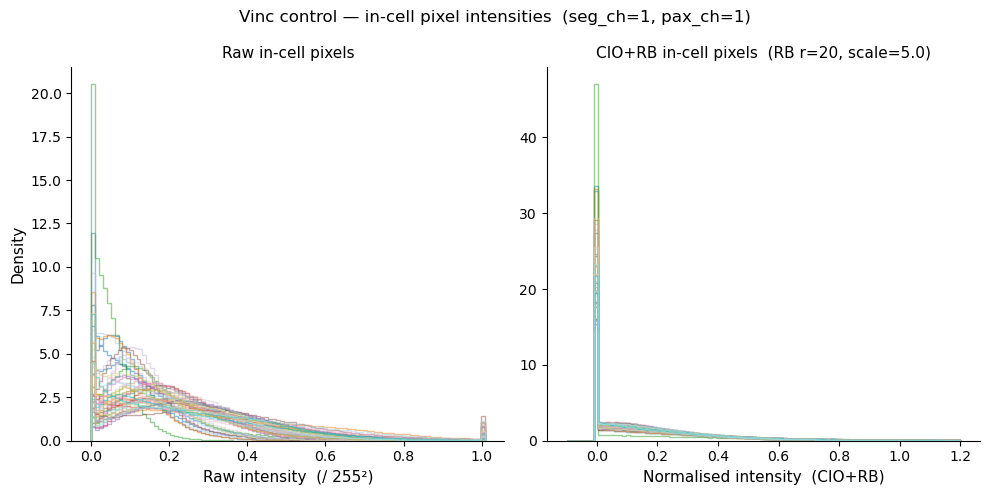

In [42]:
# ── plot histograms ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
cmap = plt.cm.tab20
n    = len(results)

for i, r in enumerate(results):
    col = cmap(i / max(n - 1, 1))

    # left: raw in-cell
    raw_vals = r["raw_inside_vals"]
    if len(raw_vals) > 0:
        axes[0].hist(raw_vals, bins=100, density=True,
                     histtype="step", color=col, alpha=0.5, label=r["name"])

    # right: CIO+RB normalised in-cell
    vals = r["inside_vals"]
    if len(vals) > 0:
        axes[1].hist(vals, bins=100, range=(-0.1, 1.2), density=True,
                     histtype="step", color=col, alpha=0.5, label=r["name"])

axes[0].set_xlabel("Raw intensity  (/ 255²)", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_title("Raw in-cell pixels", fontsize=11)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].set_xlabel("Normalised intensity  (CIO+RB)", fontsize=11)
axes[1].set_title(
    f"CIO+RB in-cell pixels  "
    f"(RB r={RB_RADIUS}, scale={CIO_SCALE})",
    fontsize=11)
# axes[1].axvline(1/CIO_SCALE, color="k", lw=1, ls="--", alpha=0.5,
#                 label=f"mean_inside ref (1/scale={1/CIO_SCALE:.2f})")
axes[1].spines[["top", "right"]].set_visible(False)

handles, labels = axes[1].get_legend_handles_labels()
# fig.legend(handles, labels, loc="lower center", ncol=10,
#            fontsize=6, frameon=False, bbox_to_anchor=(0.5, -0.12))

plt.suptitle(
    f"Vinc control — in-cell pixel intensities  (seg_ch={SEG_CH}, pax_ch={PAX_CH})",
    fontsize=12)
plt.tight_layout()
fig.savefig(OUT_PATH, dpi=150, bbox_inches="tight")
print(f"Saved → {OUT_PATH}")
plt.show()

In [38]:
# ── summary stats ─────────────────────────────────────────────────────────────
print(f'{"image":<25}  {"mean_out":>10}  {"mean_in":>10}  {"n_inside":>10}')
print('-' * 60)
for r in results:
    print(f'{r["name"]:<25}  {r["mean_out"]:>10.4f}  {r["mean_in"]:>10.4f}  {len(r["inside_vals"]):>10,}')

image                        mean_out     mean_in    n_inside
------------------------------------------------------------
lin(m)568_control-01           0.0004      0.0332     346,009
lin(m)568_control-02           0.0003      0.0287     319,340
lin(m)568_control-03           0.0004      0.0448     250,450
lin(m)568_control-04           0.0004      0.0397     416,269
lin(m)568_control-05           0.0003      0.0313     236,048
lin(m)568_control-06           0.0002      0.0283     322,585
lin(m)568_control-07           0.0017      0.0752     266,100
lin(m)568_control-08           0.0012      0.1026     274,820
lin(m)568_control-09           0.0010      0.0783     234,792
lin(m)568_control-10           0.0009      0.0594     255,454
lin(m)568_control-11           0.0001      0.0134     410,200
lin(m)568_control-12           0.0005      0.0513     230,211
lin(m)568_control-13           0.0010      0.0749     266,556
lin(m)568_control-14           0.0009      0.0893     211,825
lin(m)568